In [3]:
import cv2
import matplotlib.pyplot as plt

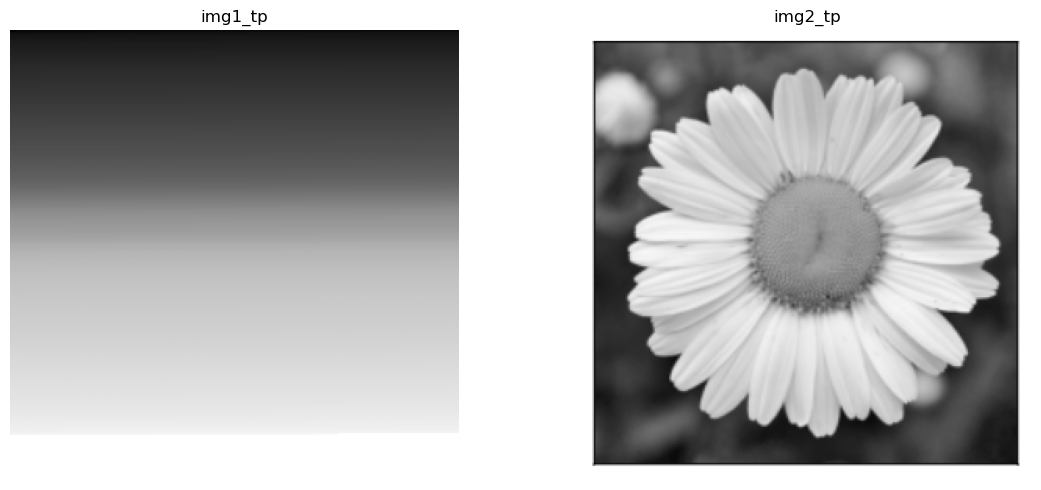

In [4]:
img1 = cv2.imread('media/img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('media/img2_tp.png', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('img1_tp')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('img2_tp')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

def plot_histograms(images, labels, bins=256):
    fig, axes = plt.subplots(1, len(images), figsize=(6 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    for ax, img, label in zip(axes, images, labels):
        hist = cv2.calcHist([img], [0], None, [bins], [0, 256])
        bin_edges = np.linspace(0, 255, bins)
        ax.plot(bin_edges, hist)
        ax.set_title(f'Histograma - {label}')
        ax.set_xlabel('Intensidad')
        ax.set_ylabel('Frecuencia')
        ax.set_xlim([0, 255])
    plt.tight_layout()
    plt.show()

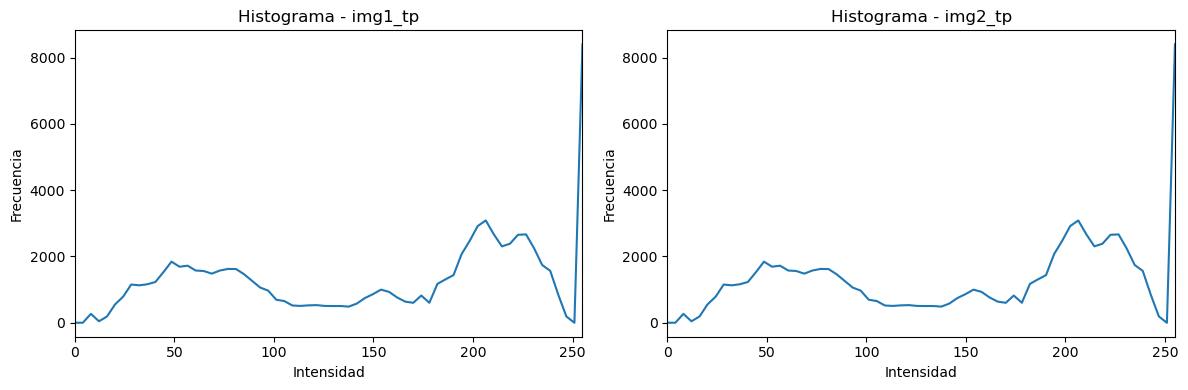

In [12]:
plot_histograms([img1, img2], ['img1_tp', 'img2_tp'], bins=64)

Ambos histogramas son visualmente iguales, independientemente de la cantidad de bins elegidos.

En cuanto a si usaría o no el histograma como una feature, supongo que dependerá de lo que este buscando resolver ya que en cierto casos la distribucion de intensidad de la imagen puede tener una correlación con lo que se quiere detectar. Probablemente no lo usaría como una feature esencial ya que como se ve en el ejemplo, muchas imagenes pueden tener el mismo histograma y ser completamente distintas lo cual se debe a que el histograma no captura información espacial. Estimo que un análisis de datos podría ayudarme a descartarlo aunque tendría principalmente en cuenta el modelo a entrenar.